In [16]:
import os
import argparse
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import scipy.io
import scipy.misc
import numpy as np
import pandas as pd
import PIL
from PIL import ImageFont,ImageDraw,Image
import tensorflow as tf
from tensorflow.python.framework.ops import EagerTensor
from tensorflow.keras.models import load_model
from yad2k.models.keras_yolo import yolo_head
%matplotlib inline

In [17]:
def yolo_filter_boxes(boxes,box_confidence,box_class_probs,threshold=0.6):
    box_scores = box_confidence*box_class_probs
    box_classes = tf.math.argmax(box_scores,axis=-1)
    box_class_scores = tf.math.reduce_max(box_scores,axis=-1)
    filtering_mask = box_class_scores >= threshold
    scores = tf.boolean_mask(box_class_scores,filtering_mask)
    boxes = tf.boolean_mask(boxes,filtering_mask)
    classes = tf.boolean_mask(box_classes,filtering_mask)
    return scores,boxes,classes

In [18]:
def iou(box1,box2):
    (box1_x1,box1_y1,box1_x2,box1_y2) = box1
    (box2_x1,box2_y1,box2_x2,box2_y2) = box2
    
    xi1 = max(box1_x1,box2_x1)
    yi1 = max(box1_y1,box2_y1)
    xi2 = max(box1_x2,box2_x2)
    yi2 = max(box1_y2,box2_y2)
    inter_width = max(xi2-xi1,0)
    inter_height = max(yi2-yi1,0)
    inter_area = inter_width*inter_height
    box1_area = (box1_x2-box1_x1)*(box1_y2-box1_y1)
    box2_area = (box2_x2-box2_x1)*(box2_y2-box2_y1)
    union_area = box1_area+box2_area-inter_area
    
    iou = inter_area/union_area
    return iou

In [19]:
def yolo_non_max_suppression(scores,boxes,classes,max_boxes=10,iou_threshold=0.5):
    boxes = tf.cast(boxes,dtype=tf.float32)
    scores = tf.cast(scores,dtype=tf.float32)
    nms_indices = []
    classes_labels = tf.unique(classes)[0]
    
    for label in classes_labels:
        filtering_mask = classes == label
        boxes_label = tf.boolean_mask(boxes,filtering_mask)
        scores_label = tf.boolean_mask(scores,filtering_mask)
        if tf.shape(scores_label)[0] > 0:
            nms_indices_label = tf.image.non_max_suppression(boxes_label,scores_label,max_boxes,iou_threshold=iou_threshold)
            selected_indices = tf.squeeze(tf.where(filtering_mask),axis=1)
            nms_indices.append(tf.gather(selected_indices,nms_indices_label))
            
    nms_indices = tf.concat(nms_indices,axis=0)
    scores = tf.gather(scores,nms_indices)
    boxes = tf.gather(boxes,nms_indices)
    classes = tf.gather(classes,nms_indices)
    
    sort_order = tf.argsort(scores,direction='DESCENDING').numpy()
    scores = tf.gather(scores,sort_order[0:max_boxes])
    boxes = tf.gather(boxes,sort_order[0:max_boxes])
    classes = tf.gather(classes,sort_order[0:max_boxes])
    
    return scores,boxes,classes

In [20]:
def yolo_boxes_to_corners(box_xy,box_wh):
    box_mins = box_xy - (box_wh/2.)
    box_maxes = box_xy + (box_wh/2.)
    
    return tf.keras.backend.concatenate([box_mins[...,1:2],box_mins[...,0:1],box_maxes[...,1:2],box_maxes[...,0:1]])

In [21]:
def yolo_eval(yolo_outputs,image_shape=(720,1280),max_boxes=50,score_threshold=0.3,iou_threshold=0.6):
    box_xy,box_wh,box_confidence,box_class_probs = yolo_outputs
    boxes = yolo_boxes_to_corners(box_xy,box_wh)
    scores,boxes,classes = yolo_filter_boxes(boxes,box_confidence,box_class_probs,threshold=score_threshold)
    boxes = scale_boxes(boxes,image_shape)
    scores,boxes,classes = yolo_non_max_suppression(scores,boxes,classes,max_boxes,iou_threshold=iou_threshold)
    
    return scores,boxes,classes

In [22]:
import imghdr
import colorsys
import random

from PIL import Image, ImageDraw, ImageFont
from tensorflow.keras import backend as K

from functools import reduce

In [23]:
def preprocess_image(img_path, model_image_size):
    image_type = imghdr.what(img_path)
    image = Image.open(img_path)
    resized_image = image.resize(tuple(reversed(model_image_size)), Image.BICUBIC)
    image_data = np.array(resized_image, dtype='float32')
    image_data /= 255.
    image_data = np.expand_dims(image_data, 0)
    return image, image_data

In [24]:
def compose(*funcs):
    if funcs:
        return reduce(lambda f, g: lambda *a, **kw: g(f(*a, **kw)), funcs)
    else:
        raise ValueError('Composition of empty sequence not supported.')

In [25]:
def read_classes(classes_path):
    with open(classes_path) as f:
        class_names = f.readlines()
    class_names = [c.strip() for c in class_names]
    return class_names

In [26]:
def read_anchors(anchors_path):
    with open(anchors_path) as f:
        anchors = f.readline()
        anchors = [float(x) for x in anchors.split(',')]
        anchors = np.array(anchors).reshape(-1, 2)
    return anchors

In [27]:
def scale_boxes(boxes, image_shape):
    height = float(image_shape[0])
    width = float(image_shape[1])
    image_dims = K.stack([height, width, height, width])
    image_dims = K.reshape(image_dims, [1, 4])
    boxes = boxes * image_dims
    return boxes

In [28]:
def get_colors_for_classes(num_classes):
    if (hasattr(get_colors_for_classes, "colors") and
            len(get_colors_for_classes.colors) == num_classes):
        return get_colors_for_classes.colors

    hsv_tuples = [(x / num_classes, 1., 1.) for x in range(num_classes)]
    colors = list(map(lambda x: colorsys.hsv_to_rgb(*x), hsv_tuples))
    colors = list(
        map(lambda x: (int(x[0] * 255), int(x[1] * 255), int(x[2] * 255)),
            colors))
    random.seed(10101)  
    random.shuffle(colors)  
    random.seed(None)
    get_colors_for_classes.colors = colors  
    return colors

In [29]:
def draw_boxes(image, boxes, box_classes, class_names, scores=None):

    font = ImageFont.truetype(
        font='font/FiraMono-Medium.otf',
        size=np.floor(3e-2 * image.size[1] + 0.5).astype('int32'))
    thickness = (image.size[0] + image.size[1]) // 300

    colors = get_colors_for_classes(len(class_names))

    for i, c in list(enumerate(box_classes)):
        box_class = class_names[int(c)]
        box = boxes[i]
        
        if tf.is_tensor(scores):
            score = scores.numpy()[i]
        else:
            score = scores[i]
        label = '{} {:.2f}'.format(box_class,score)

        draw = ImageDraw.Draw(image)
        label_size = draw.textbbox((0, 0), label, font=font)
        label_size = (
            label_size[2] - label_size[0],
            label_size[3] - label_size[1]
        )
        if tf.is_tensor(boxes):
            boxes = boxes.numpy()

        if tf.is_tensor(box_classes):
            box_classes = box_classes.numpy()

        if tf.is_tensor(scores):
            scores = scores.numpy()
            
        box = boxes[i]
        top, left, bottom, right = box
        top = max(0, np.floor(top + 0.5).astype('int32'))
        left = max(0, np.floor(left + 0.5).astype('int32'))
        bottom = min(image.size[1], np.floor(bottom + 0.5).astype('int32'))
        right = min(image.size[0], np.floor(right + 0.5).astype('int32'))
        print(label, (left, top), (right, bottom))

        if top - label_size[1] >= 0:
            text_origin = np.array([left, top - label_size[1]])
        else:
            text_origin = np.array([left, top + 1])

        for i in range(thickness):
            draw.rectangle(
                [left + i, top + i, right - i, bottom - i], outline=colors[c])
        draw.rectangle(
            [tuple(text_origin), tuple(text_origin + label_size)],
            fill=colors[c])
        draw.text(text_origin, label, fill=(0, 0, 0), font=font)
        del draw

    return np.array(image)

In [30]:
class_names = read_classes("model_data/coco_classes.txt")
anchors = read_anchors("model_data/yolo_anchors.txt")
model_image_size = (608,608)

In [31]:
yolo_model = load_model("model_data",compile=False)

In [32]:
yolo_model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 608, 608, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 608, 608, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 608, 608, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                      

                                                                                                  
 batch_normalization_8 (BatchNo  (None, 38, 38, 512)  2048       ['conv2d_8[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 leaky_re_lu_8 (LeakyReLU)      (None, 38, 38, 512)  0           ['batch_normalization_8[0][0]']  
                                                                                                  
 conv2d_9 (Conv2D)              (None, 38, 38, 256)  131072      ['leaky_re_lu_8[0][0]']          
                                                                                                  
 batch_normalization_9 (BatchNo  (None, 38, 38, 256)  1024       ['conv2d_9[0][0]']               
 rmalization)                                                                                     
          

 conv2d_20 (Conv2D)             (None, 38, 38, 64)   32768       ['leaky_re_lu_12[0][0]']         
                                                                                                  
 leaky_re_lu_18 (LeakyReLU)     (None, 19, 19, 1024  0           ['batch_normalization_18[0][0]'] 
                                )                                                                 
                                                                                                  
 batch_normalization_20 (BatchN  (None, 38, 38, 64)  256         ['conv2d_20[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 conv2d_19 (Conv2D)             (None, 19, 19, 1024  9437184     ['leaky_re_lu_18[0][0]']         
                                )                                                                 
          

In [33]:
def traffic_analysis(out_boxes, out_classes, class_names, image):

    vehicle_classes = ['car', 'bus', 'truck', 'motorbike']

    stats = {
        'car': 0,
        'bus': 0,
        'truck': 0,
        'motorbike': 0
    }

    total_vehicle_area = 0

    if hasattr(out_boxes, "numpy"):
        out_boxes = out_boxes.numpy()

    if hasattr(out_classes, "numpy"):
        out_classes = out_classes.numpy()

    for i, c in enumerate(out_classes):

        class_name = class_names[int(c)]

        if class_name in vehicle_classes:

            stats[class_name] += 1

            top, left, bottom, right = out_boxes[i]

            box_area = max(0, (right - left)) * max(0, (bottom - top))

            total_vehicle_area += box_area

    total_vehicles = sum(stats.values())

    image_width, image_height = image.size
    image_area = image_width * image_height

    density_ratio = total_vehicle_area / image_area

    if density_ratio < 0.08:
        density = "LOW"

    elif density_ratio < 0.20:
        density = "MEDIUM"

    else:
        density = "HIGH"

    print("\nTraffic Analysis")
    print(f"Cars       : {stats['car']}")
    print(f"Buses      : {stats['bus']}")
    print(f"Trucks     : {stats['truck']}")
    print(f"Motorbikes : {stats['motorbike']}")
    print(f"Total Vehicles : {total_vehicles}")
    print(f"Density Ratio  : {density_ratio:.3f}")
    print(f"Traffic Density: {density}")

    return {
        "vehicle_count": total_vehicles,
        "vehicle_stats": stats,
        "density_ratio": density_ratio,
        "traffic_density": density
    }

In [52]:
def predict(image_path):
    image,image_data = preprocess_image(image_path,model_image_size=(608,608))
    yolo_model_outputs = yolo_model(image_data)
    yolo_outputs = yolo_head(yolo_model_outputs,anchors,len(class_names))
    out_scores,out_boxes,out_classes = yolo_eval(yolo_outputs,[image.size[1],image.size[0]])
    print(f"Found {len(out_boxes)} boxes")
    colors = get_colors_for_classes(len(class_names))
    draw_boxes(image,out_boxes,out_classes,class_names,out_scores)
    analysis = traffic_analysis(out_boxes,out_classes,class_names,image)
    image_file = os.path.basename(image_path)
    image.save(os.path.join("out",image_file),quality=100)
    output_image = Image.open(os.path.join("out",image_file))
    imshow(output_image)
    
    return out_scores,out_boxes,out_classes,analysis,output_image

Found 13 boxes
car 0.89 (366, 299) (745, 648)
car 0.80 (762, 282) (942, 412)
car 0.75 (159, 303) (346, 440)
car 0.70 (947, 324) (1280, 704)
car 0.68 (705, 279) (786, 351)
bus 0.67 (5, 267) (220, 407)
car 0.60 (925, 285) (1045, 374)
car 0.45 (336, 296) (377, 335)
car 0.38 (965, 273) (1023, 292)
traffic light 0.35 (681, 195) (692, 215)
car 0.33 (410, 294) (457, 324)
car 0.32 (574, 252) (670, 312)
car 0.30 (315, 293) (384, 346)

Traffic Analysis
Cars       : 11
Buses      : 1
Trucks     : 0
Motorbikes : 0
Total Vehicles : 12
Density Ratio  : 0.403
Traffic Density: HIGH


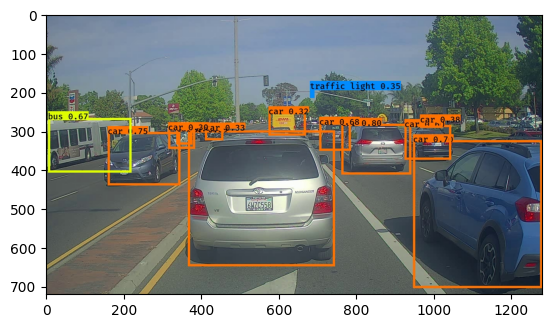

In [53]:
out_scores, out_boxes, out_classes, analysis, output_image = predict("images/test.jpg")

Found 7 boxes
car 0.81 (1083, 814) (1365, 1013)
person 0.63 (1777, 800) (1892, 995)
traffic light 0.55 (314, 63) (423, 258)
traffic light 0.54 (482, 75) (571, 251)
person 0.51 (1633, 820) (1684, 912)
person 0.35 (1319, 816) (1358, 885)
person 0.34 (1699, 837) (1831, 970)

Traffic Analysis
Cars       : 1
Buses      : 0
Trucks     : 0
Motorbikes : 0
Total Vehicles : 1
Density Ratio  : 0.023
Traffic Density: LOW


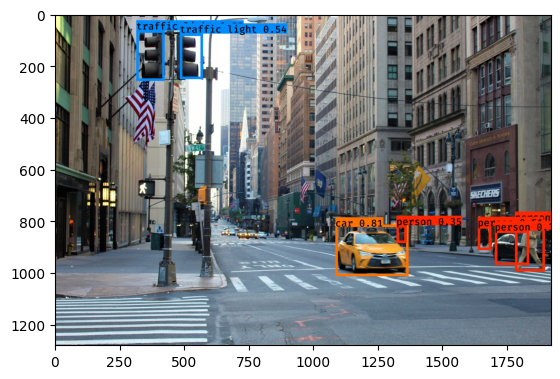

In [54]:
out_scores,out_boxes,out_classes, analysis, output_image = predict("images/new-york-city-streets.jpg")

Found 11 boxes
car 0.71 (943, 602) (1027, 650)
car 0.71 (591, 586) (661, 639)
car 0.65 (1074, 658) (1168, 711)
car 0.61 (1538, 620) (1657, 699)
car 0.58 (552, 720) (694, 860)
traffic light 0.44 (530, 444) (554, 483)
car 0.44 (796, 500) (842, 529)
traffic light 0.42 (1349, 448) (1381, 488)
traffic light 0.36 (1351, 478) (1383, 510)
traffic light 0.34 (429, 486) (462, 540)
parking meter 0.31 (297, 366) (359, 529)

Traffic Analysis
Cars       : 6
Buses      : 0
Trucks     : 0
Motorbikes : 0
Total Vehicles : 6
Density Ratio  : 0.024
Traffic Density: LOW


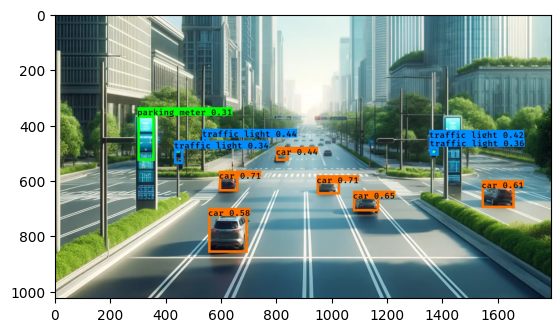

In [55]:
out_scores,out_boxes,out_classes, analysis, output_image = predict("images/modern-city.webp")